# Lab 3: A Conditional Generative Model for Images

**based on lab from MIT course ["Introduction to Flow Matching and Diffusion Models 2026"](https://diffusion.csail.mit.edu/2026/index.html)**

In [1]:
from models import VAE, DiffusionTransformerFlowModel
from trainers import VAETrainer, LatentCFGTrainer
from flow import GaussianConditionalProbabilityPath, LinearAlpha, LinearBeta
from utils.latents import (
    visualize_latent_interpolation,
    estimate_latent_stats,
    convert_to_latent_dataset,
)
from utils.fid import fid_guidance_sweep

from typing import Optional
from matplotlib import pyplot as plt
from tqdm import tqdm

import torch
from torchvision import datasets, transforms
from torchvision.utils import make_grid
from einops import rearrange
from torch.utils.data import DataLoader, TensorDataset

# Part 1. Loading datasets

In [2]:
device = torch.device("cuda:1")

cifar = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transforms.Compose(
        [
            transforms.RandomHorizontalFlip(),
            # Converts PIL Image to [0, 1] torch.Tensor
            transforms.ToTensor(),
            transforms.Normalize(  # Scales pixel values to [-1, 1]
                mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]
            ),
        ]
    ),
)

cifar_test = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transforms.Compose(
        [
            transforms.RandomHorizontalFlip(),
            # Converts PIL Image to [0, 1] torch.Tensor
            transforms.ToTensor(),
            transforms.Normalize(  # Scales pixel values to [-1, 1]
                mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]
            ),
        ]
    ),
)


def cifar_reverse_transform(x):
    x = (x + 1.0) / 2.0
    return torch.clamp(x, 0.0, 1.0)

# Part 2: Training process

## 2.1: Training a VAE

In [3]:
vae = VAE(
    data_channels=3,
    hidden_channels=[8, 16, 16],
    beta=0.01,
).to(device)

In [4]:
train_dataloader = DataLoader(dataset=cifar, batch_size=64, shuffle=True)

trainer = VAETrainer(
    dataloader=train_dataloader,
    reverse_transform=cifar_reverse_transform,
)

In [5]:
# trainer.train(
#     model=vae,
#     num_epochs=20,
#     lr=1e-3,
#     warmup_steps=500,
#     ckpt_every=5,
#     run_name="vae2",
# )

In [6]:
trainer.load(model=vae, run_name="vae", resume_from=f"epoch_{20}_state")
vae.to(device);

Loading model with size: 0.158 MiB


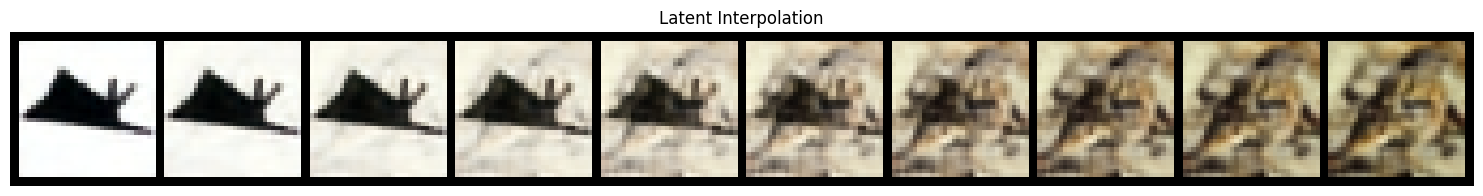

In [7]:
# Perform interpolation in the latent space
samples, _ = next(iter(DataLoader(cifar_test, batch_size=2, shuffle=True)))
samples = samples.to(device)

interpolated_samples = visualize_latent_interpolation(
    x1=samples[:1],
    x2=samples[1:2],
    vae=vae,
    n_steps=10,
    reverse_transform=cifar_reverse_transform,
)  # n_steps 3 h w

In [8]:
latent_mean, latent_std = estimate_latent_stats(vae, train_dataloader)

100%|█████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:04<00:00, 22.45it/s]


## 2.2 Training a Latent Diffusion Model

In [9]:
latent_cifar = convert_to_latent_dataset(vae, cifar)

Converting dataset to latents: 100%|██████████████████████████████████████████████████████| 196/196 [00:19<00:00, 10.25it/s]


In [10]:
# Finally, let's train!

vae = vae.to(device)

# Initialize latent probability path
c = 16
img_size = 8

path = GaussianConditionalProbabilityPath(
    shape=[c, img_size, img_size],
    alpha=LinearAlpha(),
    beta=LinearBeta(),
)

# Initialize model
dit = DiffusionTransformerFlowModel(
    img_size=img_size,
    patch_size=1,
    num_layers=12,
    c=c,
    dim=384,
    heads=8,
    final_dim=64,
    n_classes=11,
).to(device)

# Initialize trainer
trainer = LatentCFGTrainer(
    dataloader=DataLoader(dataset=latent_cifar, batch_size=256, shuffle=True),
    vae=vae,
    path=path,
    null_label=10,
    latent_stats=(latent_mean, latent_std),
    null_ratio=0.1,
    reverse_transform=cifar_reverse_transform,
)

In [ ]:
trainer.train(
    model=dit,
    num_epochs=1000,
    lr=1e-4,
    ckpt_every=100,
    run_name="dit",
    warmup_steps=5_000,
    ema_decay=0.9999,
)

In [ ]:
# trainer.load(dit, "dit", f"epoch_{1000}_state")

# Part 3: Evaluation

In [ ]:
fid_guidance_sweep(trainer, "samples/dit_jun/")

In [ ]:
!nvidia-smi